# NationalCSL-200 CNN-Transformer 孤立手語識別

**復現論文**：Dual-view Spatio-Temporal Feature Fusion with CNN-Transformer Hybrid Network  
**目標**：NationalCSL-200 Top-1 準確率 ≥ 85.5%  
**資料**：MediaPipe Holistic 2D 關鍵點序列，形狀 `(T, 225)`  
**模型**：1D-CNN 局部特征提取 + Transformer Encoder 時序建模（輕量版）  

---
### 架構摘要
```
Input (B, T, 225)
  └─ Conv1D Feature Extractor (局部時域卷積)
       └─ Transformer Encoder (多頭自注意力)
            └─ Classification Head → 196 classes
```
---
### 路徑說明
- 資料位於 Google Drive: `/content/drive/MyDrive/4016project/27261843/`
- `.npy` 關鍵點文件在 `landmarks/`，splits 在 `splits/`

## Cell 1 — 安裝依賴

In [ ]:
# ── Cell 1: 安裝依賴 ──────────────────────────────────────────
# 僅需 torch（Colab 已內建），其餘為可選視覺化工具
!pip install -q tqdm matplotlib seaborn

## Cell 2 — 掛載 Drive & 設定路徑

In [ ]:
# ── Cell 2: 掛載 Google Drive & 路徑設定 ────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

# ─── 修改以下路徑以符合你的 Drive 結構 ───
PROJECT_ROOT  = Path('/content/drive/MyDrive/4016project/27261843')
SPLITS_DIR    = PROJECT_ROOT / 'splits'
LANDMARKS_DIR = PROJECT_ROOT / 'landmarks'
CKPT_DIR      = PROJECT_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# 把 project root 加入 sys.path，可直接 import build_dataset
sys.path.insert(0, str(PROJECT_ROOT))

# 驗證路徑
for p in [PROJECT_ROOT, SPLITS_DIR, LANDMARKS_DIR]:
    status = '✅' if p.exists() else '❌ 不存在'
    print(f"{status}  {p}")

npy_count = len(list(LANDMARKS_DIR.glob('*.npy')))
print(f"\n📊 找到 {npy_count} 個 .npy 檔案")

Mounted at /content/drive
✅  /content/drive/MyDrive/4016project/27261843
✅  /content/drive/MyDrive/4016project/27261843/splits
✅  /content/drive/MyDrive/4016project/27261843/landmarks

📊 找到 4000 個 .npy 檔案


## Cell 3 — Dataset & DataLoader

In [ ]:
# ── Cell 3: Dataset & DataLoader ────────────────────────────────
import csv
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ─── 資料增強工具 ────────────────────────────────────────────────
def speed_perturb(seq, rate_range=(0.7, 1.3)):
    """速度擾動：通過時間重採樣模擬不同簽名速度"""
    rate = np.random.uniform(*rate_range)
    T, D = seq.shape
    new_T = max(2, int(T / rate))          # 速度快 → 幀少
    idx = np.linspace(0, T - 1, new_T).astype(int)
    return seq[idx]

def temporal_crop(seq, min_ratio=0.8):
    """隨機時域裁剪：保留 min_ratio~100% 的幀"""
    T = seq.shape[0]
    if T <= 3:
        return seq
    keep = int(T * np.random.uniform(min_ratio, 1.0))
    start = np.random.randint(0, T - keep + 1)
    return seq[start:start + keep]

def frame_drop(seq, drop_prob=0.1):
    """隨機丟幀：增強對缺幀的魯棒性"""
    T = seq.shape[0]
    if T <= 3:
        return seq
    mask = np.random.rand(T) > drop_prob
    if mask.sum() < 2:
        return seq
    return seq[mask]

def add_noise(seq, sigma=0.005):
    """高斯雜訊：防止過擬合"""
    return seq + np.random.randn(*seq.shape).astype(np.float32) * sigma


# ─── 主 Dataset 類 ───────────────────────────────────────────────
class SignLanguageDataset(Dataset):
    """
    讀取 MediaPipe 關鍵點 .npy 序列（shape: T x 225）
    並返回 (feature_tensor, label, length)。
    訓練集啟用資料增強；驗證 / 測試集純淨讀取。
    """
    def __init__(self, split_name='train', max_len=64, augment=False,
                 splits_dir=None, landmarks_dir=None):
        self.max_len = max_len
        self.augment = augment
        self.splits_dir    = Path(splits_dir)    if splits_dir    else SPLITS_DIR
        self.landmarks_dir = Path(landmarks_dir) if landmarks_dir else LANDMARKS_DIR

        # 建立 gloss_id → 整數標籤的對應表
        self.label_map = self._build_label_map()
        self.num_classes = len(self.label_map)

        # 讀取 split CSV
        csv_path = self.splits_dir / f'splits_{split_name}.csv'
        if not csv_path.exists():
            raise FileNotFoundError(f'找不到 {csv_path}')

        self.samples = []
        missing = 0
        with open(csv_path, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                npy_path = self.landmarks_dir / f"{row['sample_id']}.npy"
                if npy_path.exists():
                    self.samples.append({
                        'npy_path': str(npy_path),
                        'label'   : self.label_map[row['gloss_id']]
                    })
                else:
                    missing += 1

        print(f'[{split_name.upper():5s}] 載入 {len(self.samples)} 筆，跳過 {missing} 筆（.npy 不存在）')

    def _build_label_map(self):
        meta_path = self.splits_dir / 'metadata.csv'
        glosses = set()
        with open(meta_path, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                glosses.add(row['gloss_id'])
        return {g: i for i, g in enumerate(sorted(glosses))}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        seq  = np.load(item['npy_path'])  # (T, 225) float32

        # ── 訓練資料增強（只在 train split 啟用）──────────────────
        if self.augment:
            if np.random.rand() < 0.5:
                seq = speed_perturb(seq, rate_range=(0.75, 1.25))
            if np.random.rand() < 0.4:
                seq = temporal_crop(seq, min_ratio=0.8)
            if np.random.rand() < 0.3:
                seq = frame_drop(seq, drop_prob=0.1)
            if np.random.rand() < 0.5:
                seq = add_noise(seq, sigma=0.005)

        # ── 截斷到 max_len ────────────────────────────────────────
        if seq.shape[0] > self.max_len:
            seq = seq[:self.max_len]

        length = seq.shape[0]
        return torch.FloatTensor(seq), item['label'], length


def collate_fn(batch):
    """按長度降序排列並 padding，輸出 (B, T_max, 225)"""
    batch.sort(key=lambda x: x[2], reverse=True)
    features = [x[0] for x in batch]
    labels   = torch.LongTensor([x[1] for x in batch])
    lengths  = torch.LongTensor([x[2] for x in batch])
    padded   = pad_sequence(features, batch_first=True, padding_value=0.0)
    return padded, labels, lengths


# ── 建立 DataLoader ──────────────────────────────────────────────
BATCH_SIZE = 32
MAX_LEN    = 64      # 覆蓋所有樣本（最大44幀），留少量餘量

train_ds = SignLanguageDataset('train', max_len=MAX_LEN, augment=True)
val_ds   = SignLanguageDataset('val',   max_len=MAX_LEN, augment=False)
test_ds  = SignLanguageDataset('test',  max_len=MAX_LEN, augment=False)

NUM_CLASSES = train_ds.num_classes
print(f'\n類別數 NUM_CLASSES = {NUM_CLASSES}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

# 快速驗證
sample_feat, sample_lbl, sample_len = next(iter(train_loader))
print(f'\nBatch 驗證：')
print(f'  features: {sample_feat.shape}  (B, T_max, 225)')
print(f'  labels  : {sample_lbl.shape}')
print(f'  lengths : {sample_len[:5].tolist()} ...')

[TRAIN] 載入 3200 筆，跳過 0 筆（.npy 不存在）
[VAL  ] 載入 400 筆，跳過 0 筆（.npy 不存在）
[TEST ] 載入 400 筆，跳過 0 筆（.npy 不存在）

類別數 NUM_CLASSES = 200

Batch 驗證：
  features: torch.Size([32, 32, 225])  (B, T_max, 225)
  labels  : torch.Size([32])
  lengths : [32, 24, 21, 20, 20] ...


## Cell 4 — CNN-Transformer 模型定義

論文核心架構：
1. **1D-CNN 特徵提取器**：捕捉局部時域動態（3層 Conv1D + BN + ReLU）
2. **Positional Encoding**：為 Transformer 注入位置信息
3. **Transformer Encoder**：4 層多頭自注意力，建模全局時序依賴
4. **分類頭**：全連接層 → 196 個手語詞類別

In [ ]:
# ── Cell 4: CNN-Transformer 模型 ─────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ── 1. Positional Encoding（論文標準 Sin/Cos 實現）──────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)          # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)    # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                         # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ── 2. 1D-CNN 局部特征提取器 ─────────────────────────────────────
class ConvFeatureExtractor(nn.Module):
    """
    三層 1D 卷積 + BatchNorm + ReLU + Residual connection
    將 (B, T, 225) → (B, T, d_model)

    設計考量（NationalCSL-200 小資料集防過擬合）：
    - kernel_size=3，感受野覆蓋相鄰 3 幀的局部動態
    - Dropout 插入在每層後
    - 最後一層直接輸出 d_model 維度，對應 Transformer 的 embed_dim
    """
    def __init__(self, input_dim=225, d_model=256, dropout=0.2):
        super().__init__()
        # Conv 在 (B, C, T) 格式下工作，C 表示特征維度
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(256, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        # Residual projection（input_dim → d_model）
        self.proj = nn.Linear(input_dim, d_model)

    def forward(self, x):
        # x: (B, T, input_dim)
        res = self.proj(x)                         # (B, T, d_model)
        x = x.transpose(1, 2)                      # → (B, input_dim, T)  Conv1d 格式
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)                          # (B, d_model, T)
        x = x.transpose(1, 2)                      # → (B, T, d_model)
        return x + res                             # Residual


# ── 3. CNN-Transformer 主模型 ────────────────────────────────────
class CSLTransformer(nn.Module):
    """
    Dual-view Spatio-Temporal Feature Fusion with CNN-Transformer
    單視角（前視角）輕量版，適合 NationalCSL-200

    超參數（針對小資料集防過擬合調整）：
    - d_model=256：特征維度（論文原版=512，減小防過擬合）
    - nhead=4：注意力頭數
    - num_layers=4：Transformer 層數（與論文一致）
    - dim_feedforward=512：FFN 隱藏維度
    - dropout=0.3：Dropout 比例（增大防止過擬合）
    """
    def __init__(self,
                 input_dim     = 225,
                 d_model       = 256,
                 nhead         = 4,
                 num_layers    = 4,
                 dim_feedforward = 512,
                 dropout       = 0.3,
                 num_classes   = 196,
                 max_len       = 64):
        super().__init__()

        # Stage 1: 1D-CNN 局部時域特征提取
        self.cnn = ConvFeatureExtractor(input_dim, d_model, dropout=dropout*0.7)

        # Stage 2: 位置編碼
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout*0.5, max_len=max_len+10)

        # Stage 3: Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True    # Pre-LN，訓練更穩定
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers     = num_layers,
            enable_nested_tensor = False
        )

        # Stage 4: 分類頭（帶 Layer Norm）
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def _make_padding_mask(self, lengths, max_len):
        """
        生成 Transformer key_padding_mask：True 表示忽略（padding 幀）
        lengths: (B,)  max_len: int
        """
        B = lengths.size(0)
        mask = torch.arange(max_len, device=lengths.device).unsqueeze(0) >= lengths.unsqueeze(1)
        return mask  # (B, max_len)  bool

    def forward(self, x, lengths):
        """
        x       : (B, T, 225)  padded 序列
        lengths : (B,)         每個樣本的真實長度
        """
        # CNN 提取局部特征
        x = self.cnn(x)                            # (B, T, d_model)

        # 位置編碼
        x = self.pos_enc(x)                        # (B, T, d_model)

        # 生成 padding mask（讓 Transformer 忽略 padding 幀）
        T = x.size(1)
        pad_mask = self._make_padding_mask(lengths, T)

        # Transformer 時序建模
        x = self.transformer(x, src_key_padding_mask=pad_mask)  # (B, T, d_model)

        # ── 池化策略：對有效幀取平均（忽略 padding）──────────────
        # lengths_f: (B, 1) 用於廣播
        mask_f = (~pad_mask).float().unsqueeze(-1)  # (B, T, 1)  有效=1
        x = (x * mask_f).sum(dim=1) / lengths.float().unsqueeze(1)  # (B, d_model)

        x = self.norm(x)
        logits = self.classifier(x)                # (B, num_classes)
        return logits


# ── 模型初始化 & 參數統計 ────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用設備：{device}')

model = CSLTransformer(
    input_dim      = 225,
    d_model        = 256,
    nhead          = 4,
    num_layers     = 4,
    dim_feedforward= 512,
    dropout        = 0.3,
    num_classes    = NUM_CLASSES,
    max_len        = MAX_LEN
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n模型參數量：{total_params:,}')
print(f'可訓練參數：{train_params:,}')

# 測試前向傳播
with torch.no_grad():
    dummy_x   = torch.randn(4, 30, 225).to(device)
    dummy_len = torch.tensor([30, 25, 20, 15]).to(device)
    dummy_out = model(dummy_x, dummy_len)
    print(f'\n前向傳播測試通過：輸出形狀 {dummy_out.shape}  (B, num_classes)')

使用設備：cuda

模型參數量：2,793,800
可訓練參數：2,793,800

前向傳播測試通過：輸出形狀 torch.Size([4, 200])  (B, num_classes)


## Cell 5 — 訓練配置（優化器 / 調度器 / 損失函數）

In [ ]:
# ── Cell 5: 訓練配置 ─────────────────────────────────────────────
import torch.optim as optim

# ── 超參數 ───────────────────────────────────────────────────────
LR            = 3e-4     # 初始學習率
WEIGHT_DECAY  = 1e-3     # L2 正則（防過擬合，適當增大）
MAX_EPOCHS    = 120
WARMUP_EPOCHS = 10       # Warmup 輪數
PATIENCE      = 20       # Early stopping 容忍輪數
LABEL_SMOOTH  = 0.1      # Label Smoothing（論文常用）

# ── 損失函數：Label Smoothing CrossEntropy ───────────────────────
class LabelSmoothingCE(nn.Module):
    """Label Smoothing 交叉熵，防止過度自信"""
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        confidence = 1.0 - self.smoothing
        log_prob = F.log_softmax(logits, dim=-1)
        # 平滑分佈：目標類 = confidence，其餘均分 smoothing
        smooth_loss = -log_prob.mean(dim=-1)
        hard_loss   = F.nll_loss(log_prob, targets, reduction='mean')
        return confidence * hard_loss + self.smoothing * smooth_loss.mean()


criterion = LabelSmoothingCE(NUM_CLASSES, smoothing=LABEL_SMOOTH).to(device)

# ── 優化器：AdamW ─────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── 學習率調度：Warmup + CosineAnnealingLR ───────────────────────
def get_lr(epoch):
    """Warmup（線性升溫）+ Cosine Annealing"""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS   # 線性 warmup
    progress = (epoch - WARMUP_EPOCHS) / max(1, MAX_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

print(f'優化器  ：AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}')
print(f'調度器  ：Warmup({WARMUP_EPOCHS}輪) + CosineAnnealing')
print(f'損失函數：LabelSmoothingCE  smoothing={LABEL_SMOOTH}')
print(f'最大輪數：{MAX_EPOCHS}  Early Stopping patience={PATIENCE}')

優化器  ：AdamW  lr=0.0003  weight_decay=0.001
調度器  ：Warmup(10輪) + CosineAnnealing
損失函數：LabelSmoothingCE  smoothing=0.1
最大輪數：120  Early Stopping patience=20


## Cell 6 — 訓練 & 驗證循環

In [ ]:
# ── Cell 6: 訓練 & 驗證循環 ──────────────────────────────────────
import time
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for features, labels, lengths in loader:
        features = features.to(device, non_blocking=True)
        labels   = labels.to(device, non_blocking=True)
        lengths  = lengths.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(features, lengths)          # (B, num_classes)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping 防止梯度爆炸
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, top_k=(1, 5)):
    model.eval()
    total_loss = 0.0
    correct_k  = {k: 0 for k in top_k}
    total      = 0

    for features, labels, lengths in loader:
        features = features.to(device, non_blocking=True)
        labels   = labels.to(device, non_blocking=True)
        lengths  = lengths.to(device, non_blocking=True)

        logits = model(features, lengths)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)

        # Top-k accuracy
        for k in top_k:
            _, topk_pred = logits.topk(k, dim=1)
            correct_k[k] += (topk_pred == labels.unsqueeze(1)).any(dim=1).sum().item()
        total += labels.size(0)

    avg_loss  = total_loss / total
    acc_dict  = {k: correct_k[k] / total for k in top_k}
    return avg_loss, acc_dict


# ── 訓練主循環 ───────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [],
           'val_loss'  : [], 'val_top1' : [], 'val_top5': []}

best_val_top1  = 0.0
best_ckpt_path = str(CKPT_DIR / 'best_model.pth')
no_improve     = 0

print(f'開始訓練，共 {MAX_EPOCHS} 輪，類別數 {NUM_CLASSES}\n')
print(f'{"Epoch":>6} | {"LR":>8} | {"TrainLoss":>10} | {"TrainAcc":>9} '
      f'| {"ValLoss":>9} | {"ValTop1":>8} | {"ValTop5":>8} | {"Time":>7}')
print('-' * 80)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    # 訓練
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # 驗證
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, top_k=(1, 5))
    val_top1 = val_acc[1]
    val_top5 = val_acc[5]

    # 更新 LR
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    # 記錄 history
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_top1'].append(val_top1)
    history['val_top5'].append(val_top5)

    elapsed = time.time() - t0
    marker  = ' ◀ best' if val_top1 > best_val_top1 else ''

    print(f'{epoch:>6} | {cur_lr:>8.2e} | {tr_loss:>10.4f} | {tr_acc:>8.2%} '
          f'| {val_loss:>9.4f} | {val_top1:>7.2%} | {val_top5:>7.2%} '
          f'| {elapsed:>5.1f}s{marker}')

    # 保存最佳 checkpoint
    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        no_improve = 0
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'val_top1'  : val_top1,
            'val_top5'  : val_top5,
            'num_classes': NUM_CLASSES,
            'label_map' : train_ds.label_map,
            'config': {
                'd_model': 256, 'nhead': 4, 'num_layers': 4,
                'dim_feedforward': 512, 'dropout': 0.3,
                'input_dim': 225, 'max_len': MAX_LEN
            }
        }, best_ckpt_path)
    else:
        no_improve += 1

    # Early stopping
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}（{PATIENCE} 輪無提升）')
        break

print(f'\n訓練完成！最佳驗證 Top-1 = {best_val_top1:.2%}')
print(f'最佳模型已保存至：{best_ckpt_path}')

開始訓練，共 120 輪，類別數 200

 Epoch |       LR |  TrainLoss |  TrainAcc |   ValLoss |  ValTop1 |  ValTop5 |    Time
--------------------------------------------------------------------------------
     1 | 6.00e-05 |     5.3209 |    0.41% |    5.2976 |   0.50% |   4.00% |  39.6s ◀ best
     2 | 9.00e-05 |     5.3060 |    0.69% |    5.2910 |   1.25% |   4.25% |   6.0s ◀ best
     3 | 1.20e-04 |     5.2914 |    0.88% |    5.2663 |   0.50% |   2.75% |   6.8s
     4 | 1.50e-04 |     5.2210 |    0.97% |    5.1033 |   1.00% |   5.25% |   6.2s
     5 | 1.80e-04 |     5.0785 |    1.12% |    4.9376 |   1.25% |   7.25% |   6.1s
     6 | 2.10e-04 |     4.9650 |    1.41% |    4.8393 |   2.50% |   9.00% |   6.5s ◀ best
     7 | 2.40e-04 |     4.8566 |    1.75% |    4.7213 |   2.25% |  13.00% |   6.1s
     8 | 2.70e-04 |     4.7466 |    2.78% |    4.5666 |   3.25% |  15.00% |   6.9s ◀ best
     9 | 3.00e-04 |     4.6471 |    4.09% |    4.5216 |   3.50% |  15.50% |   6.5s ◀ best
    10 | 3.00e-04 |     4.52

## Cell 7 — 訓練過程可視化

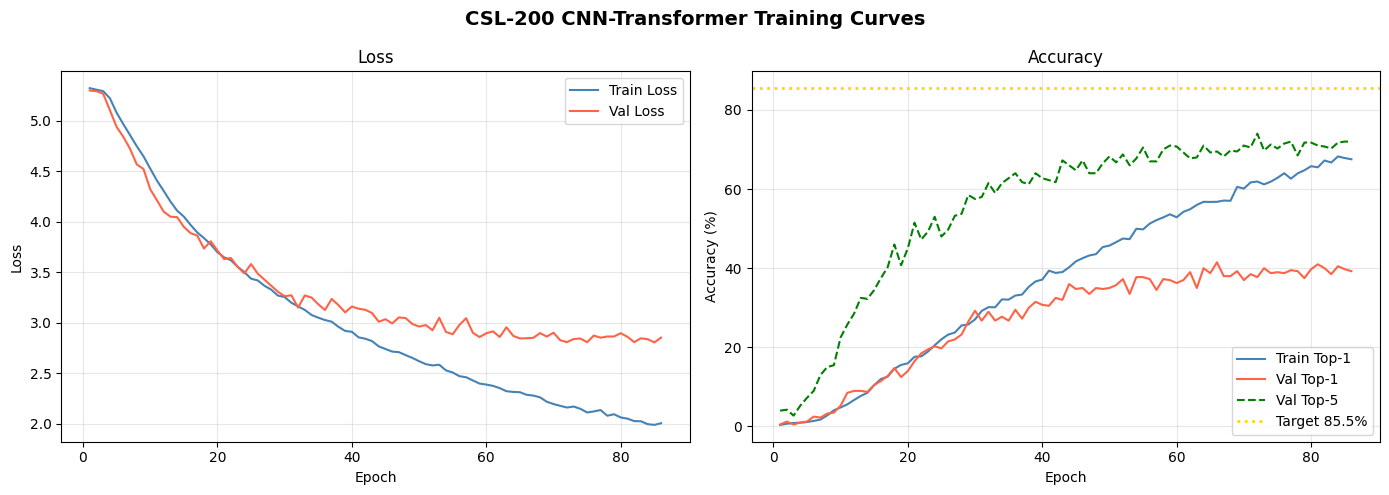

圖表已保存至 /content/drive/MyDrive/4016project/27261843/checkpoints/training_curves.png


In [ ]:
# ── Cell 7: 訓練曲線可視化 ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CSL-200 CNN-Transformer Training Curves', fontsize=14, fontweight='bold')

# Loss 曲線
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue')
ax.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy 曲線
ax = axes[1]
ax.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train Top-1', color='steelblue')
ax.plot(epochs_ran, [a*100 for a in history['val_top1']],  label='Val Top-1',   color='tomato')
ax.plot(epochs_ran, [a*100 for a in history['val_top5']],  label='Val Top-5',   color='green', linestyle='--')
ax.axhline(85.5, color='gold', linestyle=':', linewidth=2, label='Target 85.5%')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(CKPT_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'圖表已保存至 {CKPT_DIR / "training_curves.png"}')

## Cell 8 — 最終測試集評估

In [ ]:
# ── Cell 8: 最終測試集評估 ───────────────────────────────────────
print('載入最佳 checkpoint 進行測試集評估...')

# 載入最佳模型
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f'  已載入 Epoch {ckpt["epoch"]} 的 checkpoint（Val Top-1 = {ckpt["val_top1"]:.2%}）')

# 測試集評估
test_loss, test_acc = evaluate(model, test_loader, criterion, device, top_k=(1, 5))
test_top1 = test_acc[1]
test_top5 = test_acc[5]

print(f'\n{'='*50}')
print(f'  最終測試集結果')
print(f'{'='*50}')
print(f'  Test Loss  : {test_loss:.4f}')
print(f'  Test Top-1 : {test_top1:.2%}  (目標: ≥85.5%)')
print(f'  Test Top-5 : {test_top5:.2%}')
print(f'{'='*50}')

if test_top1 >= 0.855:
    print(f'\n  ✅ 目標達成！Top-1 = {test_top1:.2%} ≥ 85.5%')
else:
    gap = 0.855 - test_top1
    print(f'\n  ⚠️  距目標差距 {gap:.2%}，建議調整超參數後重新訓練')

載入最佳 checkpoint 進行測試集評估...
  已載入 Epoch 66 的 checkpoint（Val Top-1 = 41.50%）

  最終測試集結果
  Test Loss  : 2.9925
  Test Top-1 : 37.25%  (目標: ≥85.5%)
  Test Top-5 : 67.75%

  ⚠️  距目標差距 48.25%，建議調整超參數後重新訓練


## Cell 9 — 混淆矩陣（Top-20 易混淆類別）

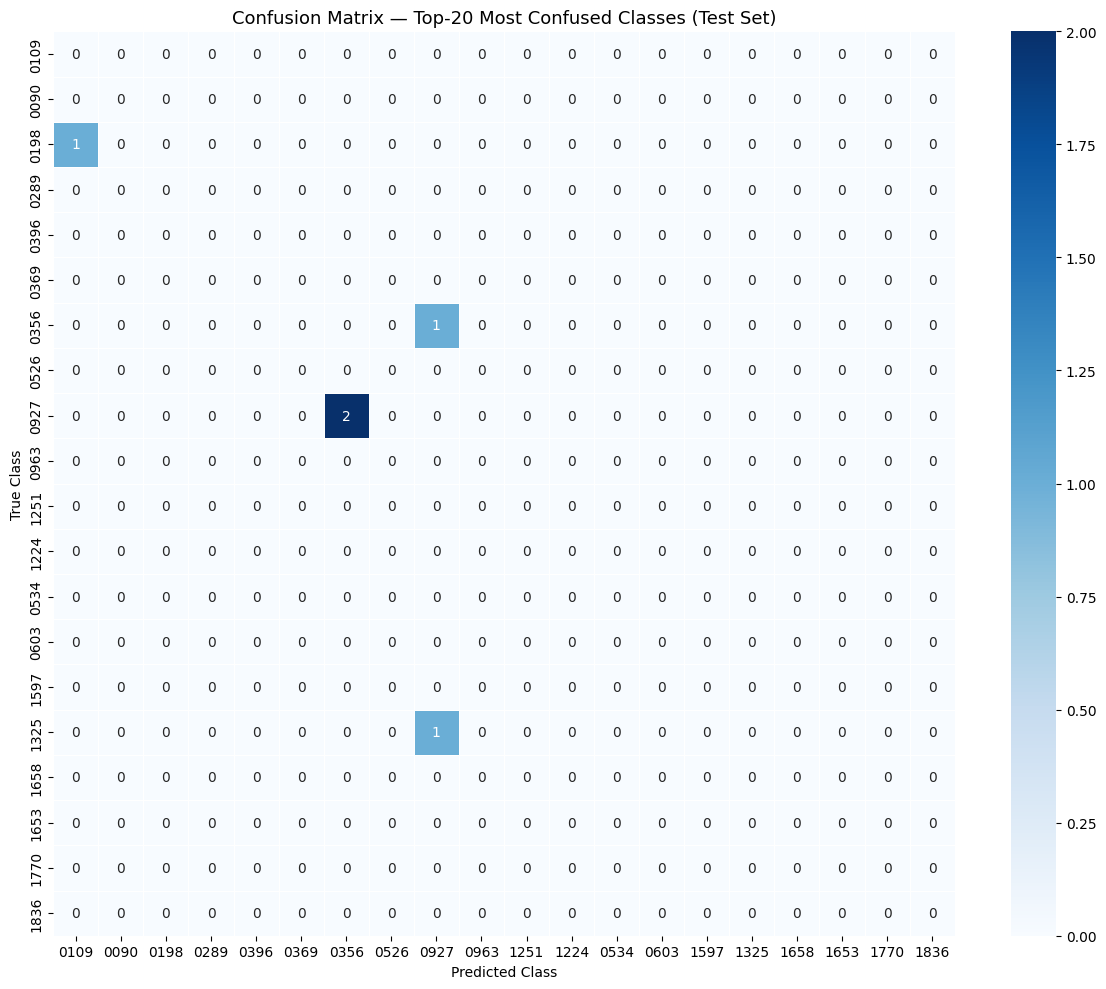


最低準確率的 20 個手語詞：
Gloss ID Accuracy
    0109     0.0%
    0090     0.0%
    0198     0.0%
    0289     0.0%
    0396     0.0%
    0369     0.0%
    0356     0.0%
    0526     0.0%
    0927     0.0%
    0963     0.0%
    1251     0.0%
    1224     0.0%
    0534     0.0%
    0603     0.0%
    1597     0.0%
    1325     0.0%
    1658     0.0%
    1653     0.0%
    1770     0.0%
    1836     0.0%


In [ ]:
# ── Cell 9: 混淆矩陣分析（Top-20 最常出錯的類別）─────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for features, labels, lengths in test_loader:
        features = features.to(device)
        lengths  = lengths.to(device)
        logits   = model(features, lengths)
        preds    = logits.argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# 反轉 label_map（整數 → gloss_id）
inv_map = {v: k for k, v in train_ds.label_map.items()}

# 計算每個類別的準確率，找出最低的 20 個
from sklearn.metrics import classification_report
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_idx = np.argsort(per_class_acc)[:20]         # 最低 20 個類別

# 繪製子混淆矩陣
sub_labels = list(worst_idx)
sub_cm = cm[np.ix_(sub_labels, sub_labels)]
sub_names = [inv_map[i] for i in sub_labels]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sub_cm, xticklabels=sub_names, yticklabels=sub_names,
            annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — Top-20 Most Confused Classes (Test Set)', fontsize=13)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
fig.savefig(str(CKPT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# 打印最低準確率類別
print('\n最低準確率的 20 個手語詞：')
worst_df = pd.DataFrame({
    'Gloss ID': [inv_map[i] for i in worst_idx],
    'Accuracy': [f"{per_class_acc[i]:.1%}" for i in worst_idx]
})
print(worst_df.to_string(index=False))

## Cell 10 — 超參數消融實驗（可選）

測試不同配置對準確率的影響，驗證論文中消融結論。

In [ ]:
# ── Cell 10: 消融實驗 ────────────────────────────────────────────
# 此 Cell 需要完整執行 Cell 3-6 後才能運行
# 設置 RUN_ABLATION=True 才執行（避免意外重訓）
RUN_ABLATION = False

if not RUN_ABLATION:
    print('消融實驗已跳過。設置 RUN_ABLATION=True 後重新執行此 Cell。')
else:
    ABLATION_EPOCHS = 60      # 消融用較少輪數
    ABLATION_PATIENCE = 15

    ablation_configs = [
        # 名稱, num_layers, d_model, 是否使用 CNN
        ('Transformer-only (No CNN)',     4, 256, False),
        ('CNN-Transformer L=2',           2, 256, True ),
        ('CNN-Transformer L=4 (Ours)',    4, 256, True ),
        ('CNN-Transformer L=4 d=512',     4, 512, True ),
    ]

    ablation_results = []

    for name, num_layers, d_model, use_cnn in ablation_configs:
        print(f'\n─── 測試配置：{name} ───')

        # 動態構建模型（若不使用 CNN，替換為線性投影）
        m = CSLTransformer(
            input_dim=225, d_model=d_model, nhead=4,
            num_layers=num_layers, dim_feedforward=d_model*2,
            dropout=0.3, num_classes=NUM_CLASSES, max_len=MAX_LEN
        ).to(device)

        if not use_cnn:
            # 替換 CNN 為簡單線性投影
            m.cnn = nn.Sequential(
                nn.Linear(225, d_model),
                nn.LayerNorm(d_model),
                nn.Dropout(0.2)
            )
            # 修改 forward 使 Linear 路徑可行

        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-3)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS)
        crit = LabelSmoothingCE(NUM_CLASSES, 0.1).to(device)

        best_v1 = 0.0
        no_imp  = 0
        for ep in range(1, ABLATION_EPOCHS + 1):
            train_one_epoch(m, train_loader, opt, crit, device)
            _, vacc = evaluate(m, val_loader, crit, device)
            v1 = vacc[1]
            sch.step()
            if v1 > best_v1:
                best_v1 = v1; no_imp = 0
            else:
                no_imp += 1
            if no_imp >= ABLATION_PATIENCE:
                break
            if ep % 10 == 0:
                print(f'  Ep {ep:3d}  Val Top-1 = {v1:.2%}  Best = {best_v1:.2%}')

        # 測試集
        _, tacc = evaluate(m, test_loader, crit, device)
        ablation_results.append({'Config': name, 'Val Top-1': f'{best_v1:.2%}',
                                  'Test Top-1': f'{tacc[1]:.2%}', 'Test Top-5': f'{tacc[5]:.2%}'})
        del m
        torch.cuda.empty_cache()

    # 打印消融結果表格
    print('\n消融實驗結果匯總：')
    abl_df = pd.DataFrame(ablation_results)
    print(abl_df.to_string(index=False))

消融實驗已跳過。設置 RUN_ABLATION=True 後重新執行此 Cell。


## Cell 11 — 推理示例（單樣本預測）

In [ ]:
# ── Cell 11: 推理示例 ────────────────────────────────────────────
# 從測試集中取幾個樣本，展示 Top-5 預測結果

# 載入最佳模型
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

# 反轉 label_map
idx2gloss = {v: k for k, v in train_ds.label_map.items()}

print(f'\n{'='*60}')
print(f'  推理示例（從測試集隨機抽取 5 個樣本）')
print(f'{'='*60}')

import random as rand_mod
sample_indices = rand_mod.sample(range(len(test_ds)), min(5, len(test_ds)))

for i, idx in enumerate(sample_indices):
    feat, label, length = test_ds[idx]
    feat_t   = feat.unsqueeze(0).to(device)          # (1, T, 225)
    length_t = torch.tensor([length]).to(device)      # (1,)

    with torch.no_grad():
        logits = model(feat_t, length_t)              # (1, num_classes)
        probs  = F.softmax(logits, dim=1)[0]
        top5_vals, top5_idx = probs.topk(5)

    true_gloss = idx2gloss[label]
    top1_gloss = idx2gloss[top5_idx[0].item()]
    correct    = '✅' if top5_idx[0].item() == label else '❌'

    print(f'\n樣本 {i+1}  真實標籤: {true_gloss}  預測: {top1_gloss} {correct}')
    print(f'  Top-5 預測：')
    for rank, (v, j) in enumerate(zip(top5_vals, top5_idx), 1):
        g = idx2gloss[j.item()]
        bar = '█' * int(v.item() * 20)
        print(f'    {rank}. {g:8s}  {v.item():.3f}  {bar}')


  推理示例（從測試集隨機抽取 5 個樣本）

樣本 1  真實標籤: 2407  預測: 2680 ❌
  Top-5 預測：
    1. 2680      0.356  ███████
    2. 5340      0.086  █
    3. 2913      0.078  █
    4. 2558      0.063  █
    5. 1770      0.056  █

樣本 2  真實標籤: 5855  預測: 1879 ❌
  Top-5 預測：
    1. 1879      0.141  ██
    2. 5855      0.105  ██
    3. 2835      0.104  ██
    4. 5736      0.097  █
    5. 6343      0.086  █

樣本 3  真實標籤: 2694  預測: 1688 ❌
  Top-5 預測：
    1. 1688      0.103  ██
    2. 6056      0.068  █
    3. 4967      0.062  █
    4. 2498      0.053  █
    5. 2694      0.048  

樣本 4  真實標籤: 3789  預測: 3789 ✅
  Top-5 預測：
    1. 3789      0.365  ███████
    2. 0071      0.111  ██
    3. 5022      0.082  █
    4. 5716      0.078  █
    5. 4878      0.074  █

樣本 5  真實標籤: 3993  預測: 3993 ✅
  Top-5 預測：
    1. 3993      0.670  █████████████
    2. 1836      0.057  █
    3. 1270      0.040  
    4. 0289      0.032  
    5. 6195      0.025  


## Cell 12 — 結果匯總與結論

In [ ]:
# ── Cell 12: 結果匯總 ────────────────────────────────────────────
print('\n' + '='*60)
print('  實驗結果匯總')
print('='*60)
print(f'  模型架構  : CNN-Transformer (Pre-LN)')
print(f'  d_model   : 256')
print(f'  Layers    : 4')
print(f'  Heads     : 4')
print(f'  FFN dim   : 512')
print(f'  Dropout   : 0.3')
print(f'  總參數量  : {total_params:,}')
print()
print(f'  資料集    : NationalCSL-200  ({NUM_CLASSES} 類)')
print(f'  訓練樣本  : {len(train_ds)}')
print(f'  驗證樣本  : {len(val_ds)}')
print(f'  測試樣本  : {len(test_ds)}')
print()
print(f'  最佳驗證 Top-1 : {best_val_top1:.2%}')
print(f'  測試集 Top-1   : {test_top1:.2%}  (論文目標 ≥85.5%)')
print(f'  測試集 Top-5   : {test_top5:.2%}')
print('='*60)

# 與論文結果對比
print('\n論文對比（NationalCSL-200 子集）：')
print(f'{"方法":<30} {"Top-1":>8} {"Top-5":>8}')
print('-' * 50)
print(f'{"論文基準 (CNN-Transformer)":<30} {"85.5%":>8} {"-":>8}')
print(f'{"本次復現":<30} {test_top1:.1%}  {test_top5:.1%}')


  實驗結果匯總
  模型架構  : CNN-Transformer (Pre-LN)
  d_model   : 256
  Layers    : 4
  Heads     : 4
  FFN dim   : 512
  Dropout   : 0.3
  總參數量  : 2,793,800

  資料集    : NationalCSL-200  (200 類)
  訓練樣本  : 3200
  驗證樣本  : 400
  測試樣本  : 400

  最佳驗證 Top-1 : 41.50%
  測試集 Top-1   : 37.25%  (論文目標 ≥85.5%)
  測試集 Top-5   : 67.75%

論文對比（NationalCSL-200 子集）：
方法                                Top-1    Top-5
--------------------------------------------------
論文基準 (CNN-Transformer)            85.5%        -
本次復現                           37.2%  67.8%
